In [1]:
# 第2章｜常用技術指標：每次開啟 notebook，先執行這一格（安裝套件、登入 FinLab、開啟資料快取）
%pip install -q finlab==2.0.21 ta-lib==0.8.1
import finlab
from finlab import data

finlab.login()
data.set_storage(data.FileStorage())

Note: you may need to restart the kernel to use updated packages.


已登入（使用快取憑證）。


# 常用技術指標

**對應影片**：第 2 章 單元 8「常用技術指標」

**和影片的差異**

| 影片（2018） | 新版教材 |
| --- | --- |
| 安裝 TA-Lib 要先編譯 C 函式庫，很多人卡關 | `pip install ta-lib`（0.6 版之後）直接裝好，Windows、Mac、Colab 都一樣 |
| `data.talib('RSI')` | `data.indicator('RSI')`，一次算好所有股票 |
| `ml.talib_features(...)` 產生多組參數的特徵 | 在這裡自己寫一個小函式產生，第 3 章會用到 |

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import talib
from talib import abstract

STOCK_ID = '0050'

prices = pd.DataFrame({
    field: data.get(f'price:{name}')[STOCK_ID]
    for field, name in [('open', '開盤價'), ('high', '最高價'), ('low', '最低價'), ('close', '收盤價'), ('volume', '成交股數')]
}).dropna().astype(float)
prices.tail()

,open,high,low,close,volume
date,,,,,
2018-12-24,74.85,75.00,74.55,74.70,5952329.0
2018-12-25,74.15,74.15,73.30,73.75,12071254.0
2018-12-26,74.00,74.30,73.50,73.55,8919969.0
2018-12-27,74.80,75.15,74.50,75.05,9615359.0
2018-12-28,75.10,75.50,74.85,75.50,4629875.0


## 1. 直接呼叫 TA-Lib

每個指標都是一個函式，傳入價格就會算好。例如 RSI（相對強弱指標）：

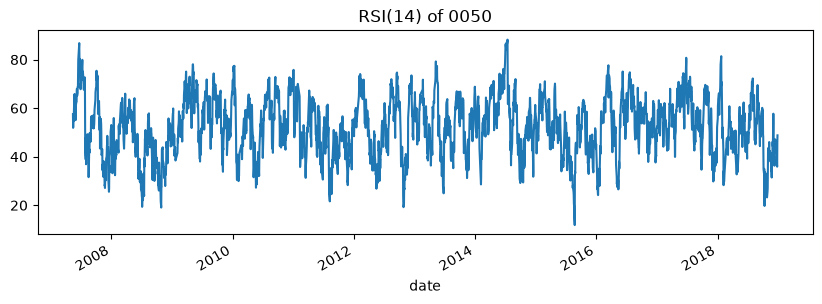

In [3]:
talib.RSI(prices['close'], timeperiod=14).plot(figsize=(10, 3), title=f'RSI(14) of {STOCK_ID}');

## 2. abstract 介面：直接傳入整張價格表

有些指標需要開高低收量好幾種價格。abstract 介面會自動從欄位名稱 `open`、`high`、`low`、`close`、`volume` 找到需要的資料。

In [4]:
stoch = abstract.STOCH(prices)
stoch.tail()

,slowk,slowd
date,,
2018-12-24,30.069444,32.233016
2018-12-25,21.111111,26.241582
2018-12-26,16.495726,22.558761
2018-12-27,42.471702,26.692847
2018-12-28,69.138369,42.701933


## 3. 計算所有技術指標

TA-Lib 把 150 多個函式分成幾類：

In [5]:
groups = talib.get_function_groups()
{group: len(functions) for group, functions in groups.items()}

{'Cycle Indicators': 5,
 'Math Operators': 12,
 'Math Transform': 15,
 'Momentum Indicators': 47,
 'Overlap Studies': 25,
 'Pattern Recognition': 61,
 'Price Transform': 6,
 'Statistic Functions': 11,
 'Volatility Indicators': 7,
 'Volume Indicators': 12}

K 線型態在上一個單元用過了；數學運算類（Math Operators、Math Transform）只是加減乘除與三角函數，不算技術指標。
其餘類別中，只要需要的輸入都在價格表裡，就計算出來。

In [6]:
INDICATOR_GROUPS = [
    'Overlap Studies', 'Momentum Indicators', 'Volume Indicators', 'Volatility Indicators',
    'Cycle Indicators', 'Price Transform', 'Statistic Functions',
]


def required_inputs(function: abstract.Function) -> set[str]:
    inputs = set()
    for value in function.input_names.values():
        inputs.update(value if isinstance(value, list) else [value])
    return inputs


indicators = {}
for group in INDICATOR_GROUPS:
    for name in groups[group]:
        function = abstract.Function(name)
        if required_inputs(function) <= set(prices.columns):
            indicators[name] = function(prices)

skipped = [name for group in INDICATOR_GROUPS for name in groups[group] if name not in indicators]
print(f'算好 {len(indicators)} 個指標；需要其他輸入而跳過的：{skipped}')

算好 112 個指標；需要其他輸入而跳過的：['MAVP']


挑幾個常用指標畫出最近一年的走勢：

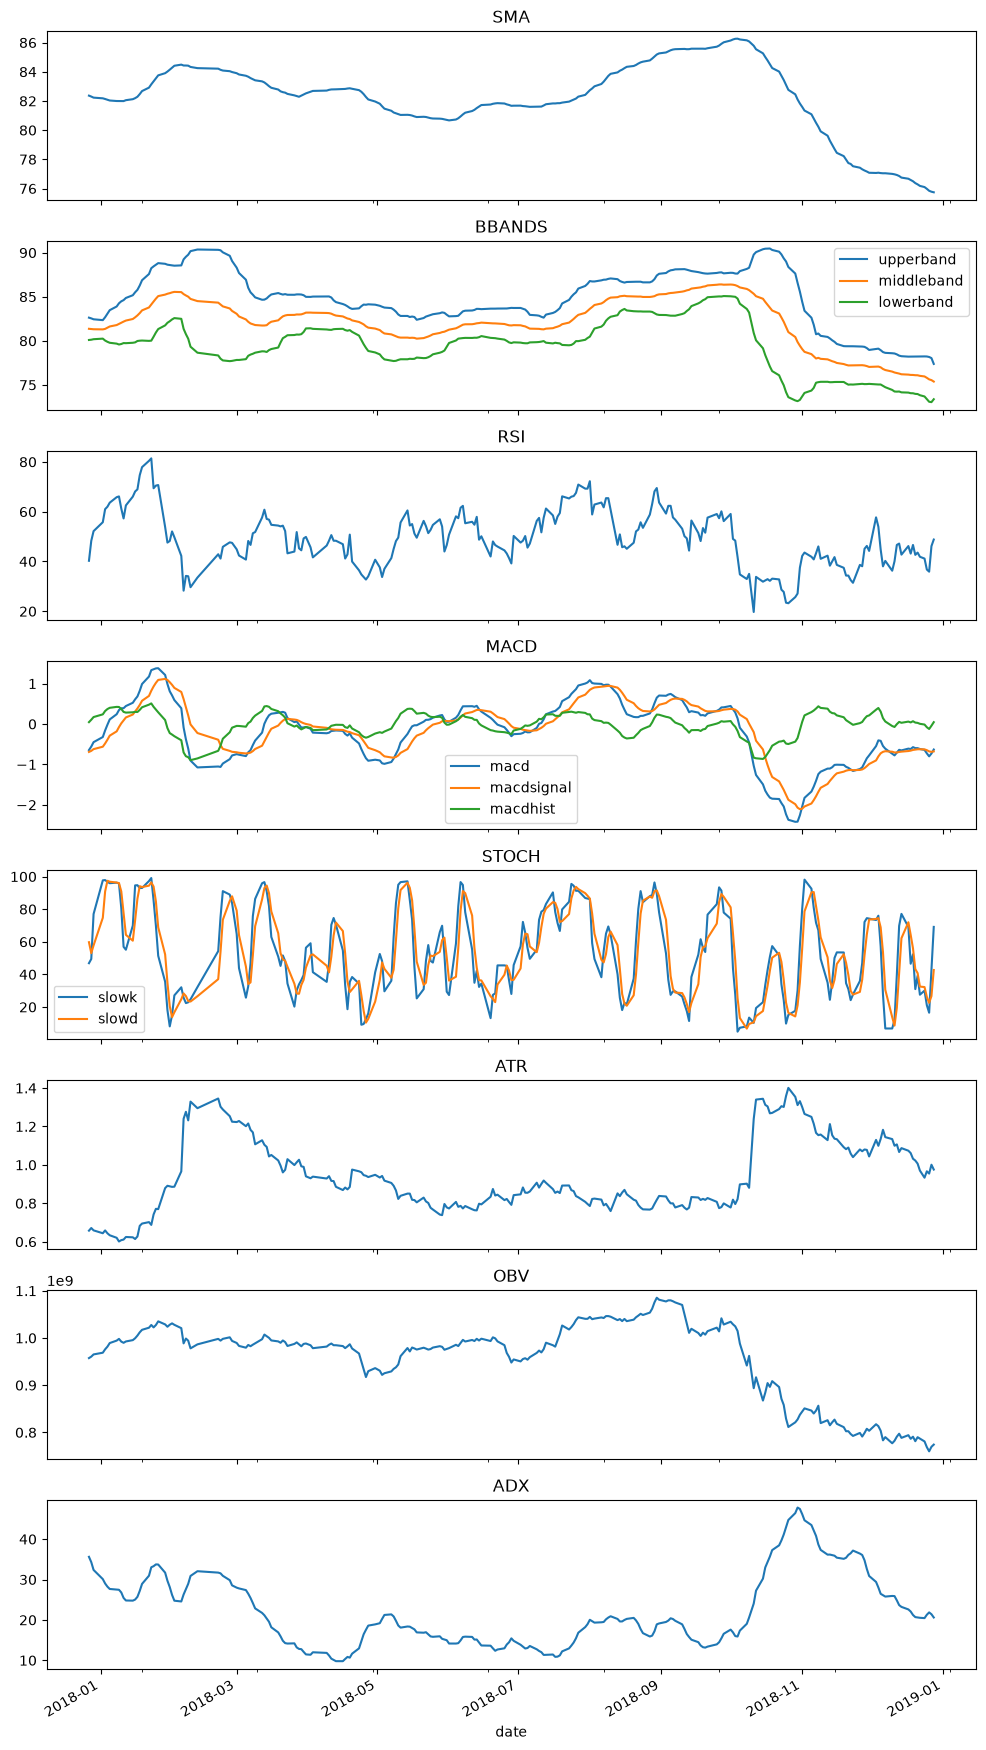

In [7]:
RECENT_DAYS = 250
SHOWCASE = ['SMA', 'BBANDS', 'RSI', 'MACD', 'STOCH', 'ATR', 'OBV', 'ADX']

fig, axes = plt.subplots(len(SHOWCASE), 1, figsize=(10, 2.2 * len(SHOWCASE)), sharex=True)
for ax, name in zip(axes, SHOWCASE):
    indicators[name].tail(RECENT_DAYS).plot(ax=ax, title=name, legend=isinstance(indicators[name], pd.DataFrame))
plt.tight_layout()

## 4. 指標的參數

每個指標都有預設參數，也可以查輸出有哪些欄位：

In [8]:
print('parameters  :', dict(abstract.STOCH.parameters))
print('output_names:', abstract.STOCH.output_names)

parameters  : {'fastk_period': 5, 'slowk_period': 3, 'slowk_matype': 0, 'slowd_period': 3, 'slowd_matype': 0}
output_names: ['slowk', 'slowd']


### 小教室：用字典傳參數

`func(**params)` 會把字典展開成關鍵字參數，`func(a=1, b=2)` 和 `func(**{'a': 1, 'b': 2})` 是一樣的。

In [9]:
def add(a, b):
    return a + b


params = {'a': 1, 'b': 2}
add(**params)

3

利用這個技巧，可以把指標的「期間」參數一次放大好幾倍。`matype` 是均線種類，不是期間，不能放大。

In [10]:
def scale_periods(parameters: dict, multiplier: int) -> dict:
    return {key: value * multiplier if key.endswith('period') else value for key, value in parameters.items()}


scale_periods(dict(abstract.STOCH.parameters), 3)

{'fastk_period': 15,
 'slowk_period': 9,
 'slowk_matype': 0,
 'slowd_period': 9,
 'slowd_matype': 0}

## 5. 製作技術指標特徵

同一個指標用不同期間計算，就得到一組特徵，第 3 章的機器學習會用到：

In [11]:
def indicator_features(prices: pd.DataFrame, names: list[str], multipliers: list[int]) -> pd.DataFrame:
    """每個指標乘上不同的期間倍數計算，回傳以「指標_輸出_倍數」命名的特徵表。"""
    features = {}
    for name in names:
        function = abstract.Function(name)
        for multiplier in multipliers:
            output = function(prices, **scale_periods(dict(function.parameters), multiplier))
            output = output.to_frame(name) if isinstance(output, pd.Series) else output.add_prefix(f'{name}_')
            for column in output.columns:
                features[f'{column}_x{multiplier}'] = output[column]
    return pd.DataFrame(features)


features = indicator_features(prices, ['STOCH', 'RSI', 'ADOSC'], [1, 3, 5, 10])
features.dropna().tail()

,STOCH_slowk_x1,STOCH_slowd_x1,STOCH_slowk_x3,STOCH_slowd_x3,STOCH_slowk_x5,STOCH_slowd_x5,STOCH_slowk_x10,STOCH_slowd_x10,RSI_x1,RSI_x3,RSI_x5,RSI_x10,ADOSC_x1,ADOSC_x3,ADOSC_x5,ADOSC_x10
date,,,,,,,,,,,,,,,,
2018-12-24,30.069444,32.233016,21.399314,25.221699,19.575240,33.365028,13.827630,17.311588,41.161881,42.161997,43.703938,46.320362,2.474925e+06,-3.388788e+06,-7.849248e+06,-5.770504e+06
2018-12-25,21.111111,26.241582,18.444109,23.156581,17.464193,31.726927,13.337754,17.123282,36.775396,40.672091,42.747500,45.774584,2.363952e+06,-2.704052e+06,-7.258623e+06,-5.653933e+06
2018-12-26,16.495726,22.558761,17.114363,21.874583,17.390290,30.289109,12.685283,16.947830,35.907832,40.364476,42.548627,45.660506,-3.797518e+05,-3.214162e+06,-7.396054e+06,-5.888813e+06
2018-12-27,42.471702,26.692847,19.527748,21.465193,18.557953,29.052008,12.997577,16.800871,46.165545,43.639494,44.512755,46.664589,6.504155e+05,-2.652561e+06,-6.904288e+06,-5.799012e+06
2018-12-28,69.138369,42.701933,25.090935,21.978776,21.131052,28.149410,13.642095,16.666153,48.812320,44.574903,45.084151,46.960721,2.485861e+06,-1.570767e+06,-6.059852e+06,-5.502238e+06


## 6. 一次算所有股票：`data.indicator`

`data.indicator` 用法和 abstract 介面一樣，差別是一次算好上市櫃所有股票，回傳「日期 × 股票」的表。
有多個輸出的指標（例如 STOCH）會回傳多張表。

In [12]:
rsi = data.indicator('RSI', timeperiod=14)
k, d = data.indicator('STOCH', fastk_period=9, slowk_period=3, slowd_period=3)

rsi[['2330', '2317', '2454']].tail()

,2330,2317,2454
date,,,
2018-12-24,43.420778,48.840976,44.267631
2018-12-25,40.630542,46.256257,40.979816
2018-12-26,39.536127,44.446889,40.176443
2018-12-27,49.128054,47.119981,45.888488
2018-12-28,52.264669,47.119981,50.471991


例如找出「RSI 小於 30（超賣）且 K 值向上穿越 D 值」的股票。
`(k > d).is_entry()` 代表「今天 K > D，昨天還不是」，也就是黃金交叉那一天。

In [13]:
OVERSOLD_RSI = 30

signal = (rsi < OVERSOLD_RSI) & (k > d).is_entry()
signal.sum(axis=1).tail()

date
2018-12-24    12
2018-12-25    13
2018-12-26     7
2018-12-27    11
2018-12-28     6
dtype: int64